In [3]:
sentence_1 = "i had a great time at the movie it was really funny"
sentence_2 = "i had a great time at the movie but the parking was terrible"
sentence_3 = "i had a great time at the movie but the parking wasn't great"
sentence_4 = "i went to see a movie"

## **TextBlob**

In [7]:
from textblob import TextBlob

In [10]:
print(sentence_1)
sentiment_score_1 = TextBlob(sentence_1)
print(sentiment_score_1.sentiment.polarity)

i had a great time at the movie it was really funny
0.525


In [11]:
print(sentence_2)
sentiment_score_2 = TextBlob(sentence_2)
print(sentiment_score_2.sentiment.polarity)

i had a great time at the movie but the parking was terrible
-0.09999999999999998


In [13]:
print(sentence_3)
sentiment_score_3 = TextBlob(sentence_3)
print(sentiment_score_3.sentiment.polarity)

i had a great time at the movie but the parking wasn't great
0.8


In [14]:
print(sentence_4)
sentiment_score_4 = TextBlob(sentence_4)
print(sentiment_score_4.sentiment.polarity)

i went to see a movie
0.0


In [18]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [20]:
vader_sentiment = SentimentIntensityAnalyzer()

In [21]:
print(sentence_1)
print(vader_sentiment.polarity_scores(sentence_1))

i had a great time at the movie it was really funny
{'neg': 0.0, 'neu': 0.578, 'pos': 0.422, 'compound': 0.807}


In [22]:
print(sentence_2)
print(vader_sentiment.polarity_scores(sentence_2))

i had a great time at the movie but the parking was terrible
{'neg': 0.234, 'neu': 0.621, 'pos': 0.144, 'compound': -0.3818}


In [23]:
print(sentence_3)
print(vader_sentiment.polarity_scores(sentence_3))

i had a great time at the movie but the parking wasn't great
{'neg': 0.247, 'neu': 0.611, 'pos': 0.142, 'compound': -0.4387}


In [24]:
print(sentence_4)
print(vader_sentiment.polarity_scores(sentence_4))

i went to see a movie
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}


## **Pre-trained Transformer**

In [6]:
import transformers
from transformers import pipeline

In [7]:
sentiment_pipeline = pipeline('sentiment-analysis')

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [10]:
print(sentence_1)
sentiment_pipeline(sentence_1)

i had a great time at the movie it was really funny


[{'label': 'POSITIVE', 'score': 0.9998176693916321}]

In [14]:
print(sentence_2)
sentiment_pipeline(sentence_2)

i had a great time at the movie but the parking was terrible


[{'label': 'NEGATIVE', 'score': 0.9977464079856873}]

In [17]:
print(sentence_3)
sentiment_pipeline(sentence_3)

i had a great time at the movie but the parking wasn't great


[{'label': 'NEGATIVE', 'score': 0.9984902143478394}]

In [18]:
print(sentence_4)
sentiment_pipeline(sentence_4)

i went to see a movie


[{'label': 'POSITIVE', 'score': 0.9802700281143188}]

In [19]:
specific_model = pipeline('sentiment-analysis', model='finiteautomata/bertweet-base-sentiment-analysis')

config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  540MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/338 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


In [21]:
print(sentence_1)
print(specific_model(sentence_1))

i had a great time at the movie it was really funny
[{'label': 'POS', 'score': 0.9923344254493713}]


In [22]:
print(sentence_2)
print(specific_model(sentence_2))

i had a great time at the movie but the parking was terrible
[{'label': 'NEG', 'score': 0.5355539917945862}]


In [23]:
print(sentence_3)
print(specific_model(sentence_3))

i had a great time at the movie but the parking wasn't great
[{'label': 'POS', 'score': 0.623441755771637}]


In [24]:
print(sentence_4)
print(specific_model(sentence_4))

i went to see a movie
[{'label': 'NEU', 'score': 0.9007406234741211}]


# **Practic**

In [27]:
import pandas as pd
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline

In [29]:
data = pd.read_csv("book_reviews_sample.csv")

In [30]:
data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [31]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   index       100 non-null    int64
 1   reviewText  100 non-null    str  
 2   rating      100 non-null    int64
dtypes: int64(2), str(1)
memory usage: 2.5 KB


In [32]:
data["reviewText"][0]

'Clean and funny. A bit busy with all the different plots going on. But overall a good read. Bye now.'

In [35]:
data['reviewText_clean'] = data['reviewText'].apply(lambda s: re.sub(r"[^\s\w]", '', s.lower()))

In [36]:
data.head()

,index,reviewText,rating,reviewText_clean
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


In [39]:
veder_sentiment = SentimentIntensityAnalyzer()

In [44]:
data['sentiment_score'] = data['reviewText_clean'].apply(lambda text: veder_sentiment.polarity_scores(text)['compound'])

In [45]:
data.head()

,index,reviewText,rating,reviewText_clean,sentiment_score
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767


In [47]:
bins = [-1, -0.1, 0.1, 1]
names = ["negative", "neutral", "positive"]
data['vader_sentiment_label'] = pd.cut(data['sentiment_score'], bins, labels=names)

In [48]:
data.head()

,index,reviewText,rating,reviewText_clean,sentiment_score,vader_sentiment_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,positive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,positive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative


<Axes: xlabel='vader_sentiment_label'>

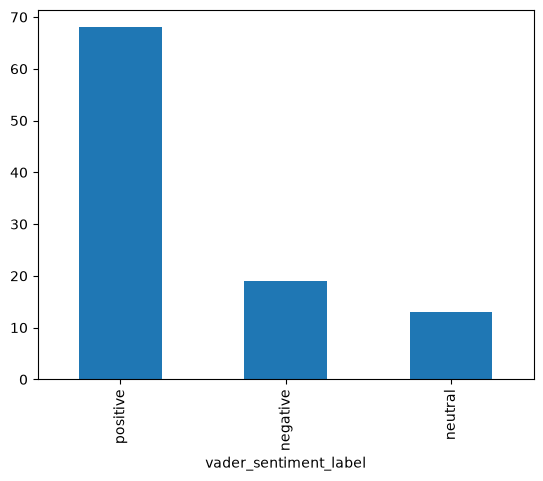

In [49]:
data['vader_sentiment_label'].value_counts().plot.bar()

In [51]:
transformer_pipeline = pipeline('sentiment-analysis')

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [64]:
transformer_labels = []

for review in data['reviewText_clean'].values:
    sentiment_list = transformer_pipeline(review)
    sentiment_label = [sent['label'] for sent in sentiment_list]
    transformer_labels.append(sentiment_label)
    

In [65]:
data['transformer_sentiment_label'] = transformer_labels

In [67]:
data.head()

,index,reviewText,rating,reviewText_clean,sentiment_score,vader_sentiment_label,transformer_sentiment_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,positive,[POSITIVE]
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,positive,[POSITIVE]
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,positive,[NEGATIVE]
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,positive,[NEGATIVE]
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative,[NEGATIVE]


<Axes: xlabel='transformer_sentiment_label'>

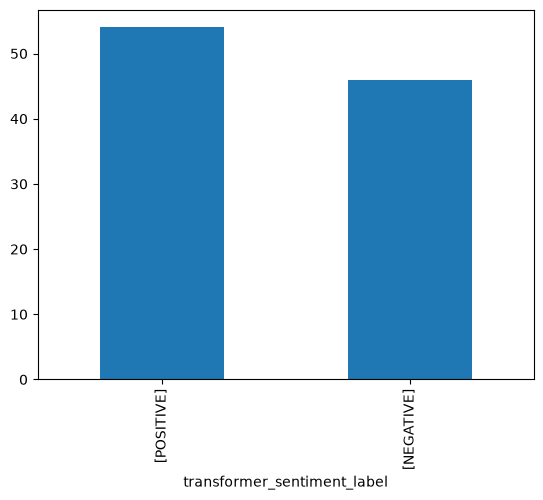

In [68]:
data['transformer_sentiment_label'].value_counts().plot.bar()

In [73]:
review_sentiment = pipeline(
    "sentiment-analysis", 
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [74]:
review_sentiment(data["reviewText_clean"][0])

[{'label': 'positive', 'score': 0.8868966102600098}]

In [75]:
data['reviewText_sentiment_analysis_roberta'] = data['reviewText_clean'].apply(lambda text: review_sentiment(text)[0]['label'])

In [76]:
data.head()

,index,reviewText,rating,reviewText_clean,sentiment_score,vader_sentiment_label,transformer_sentiment_label,reviewText_sentiment_analysis_roberta
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,positive,[POSITIVE],positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,positive,[POSITIVE],positive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,positive,[NEGATIVE],negative
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,positive,[NEGATIVE],negative
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative,[NEGATIVE],negative


<Axes: xlabel='reviewText_sentiment_analysis_roberta'>

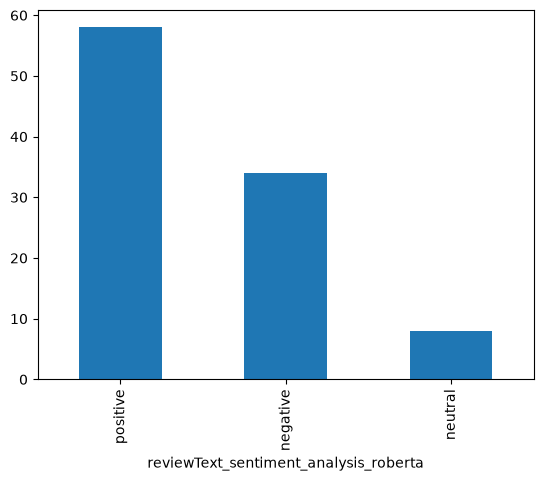

In [78]:
data['reviewText_sentiment_analysis_roberta'].value_counts().plot.bar()